## Things to be accomplished on this project
### Exploratory data analysis (EDA), Data Preprocessing, Data Cleaning, Feature Encoding, Various Machine Learning Algorithms, Hyperparameter Tuning, Model comparison

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

import warnings
warnings.filterwarnings('ignore')
plt.style.use('fivethirtyeight')
sns.set()
plt.style.use('ggplot')
%matplotlib inline

In [4]:
df = pd.read_csv(r'C:\Users\HP\Desktop\ml-kidney\data\kidney_disease.csv')

In [5]:
df.head()

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd


In [6]:
# count the classifications involved here
df['classification'].value_counts()

classification
ckd       248
notckd    150
ckd\t       2
Name: count, dtype: int64

##### ckd=chronic kidney disease

In [7]:
df.shape

(400, 26)

##### 400 rows and 26 columns

In [8]:
df.drop('id',axis=1, inplace=True)

In [9]:
df.columns

Index(['age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr', 'bu',
       'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc', 'htn', 'dm', 'cad',
       'appet', 'pe', 'ane', 'classification'],
      dtype='object')

#### Rename the different columns

In [10]:
df.columns = ['age', 'blood_pressure', 'specific_gravity', 'albumin', 'sugar', 'red_blood_cells', 'pus_cell', 'pus_cell_clumps', 'bacteria',
              'blood_glucose_random', 'blood_urea', 'serum_creatinine', 'sodium',
              'potassium', 'haemoglobin', 'packed_cell_volume', 'white_blood_cell_count', 'red_blood_cell_count', 'hypertension', 'diabetes_mellitus', 
              'coronary_artery_disease', 'appetite', 'peda_edema', 'anemia', 'class']

In [11]:
df.head()

,age,blood_pressure,specific_gravity,albumin,sugar,red_blood_cells,pus_cell,pus_cell_clumps,bacteria,blood_glucose_random,...,packed_cell_volume,white_blood_cell_count,red_blood_cell_count,hypertension,diabetes_mellitus,coronary_artery_disease,appetite,peda_edema,anemia,class
0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,...,35,7300,4.6,no,no,no,good,no,no,ckd


In [12]:
# lets see the description of the data

df.describe()

,age,blood_pressure,specific_gravity,albumin,sugar,blood_glucose_random,blood_urea,serum_creatinine,sodium,potassium,haemoglobin
count,391.000000,388.000000,353.000000,354.000000,351.000000,356.000000,381.000000,383.000000,313.000000,312.000000,348.000000
mean,51.483376,76.469072,1.017408,1.016949,0.450142,148.036517,57.425722,3.072454,137.528754,4.627244,12.526437
std,17.169714,13.683637,0.005717,1.352679,1.099191,79.281714,50.503006,5.741126,10.408752,3.193904,2.912587
min,2.000000,50.000000,1.005000,0.000000,0.000000,22.000000,1.500000,0.400000,4.500000,2.500000,3.100000
25%,42.000000,70.000000,1.010000,0.000000,0.000000,99.000000,27.000000,0.900000,135.000000,3.800000,10.300000
50%,55.000000,80.000000,1.020000,0.000000,0.000000,121.000000,42.000000,1.300000,138.000000,4.400000,12.650000
75%,64.500000,80.000000,1.020000,2.000000,0.000000,163.000000,66.000000,2.800000,142.000000,4.900000,15.000000
max,90.000000,180.000000,1.025000,5.000000,5.000000,490.000000,391.000000,76.000000,163.000000,47.000000,17.800000


In [13]:
# lets see the information of the dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      391 non-null    float64
 1   blood_pressure           388 non-null    float64
 2   specific_gravity         353 non-null    float64
 3   albumin                  354 non-null    float64
 4   sugar                    351 non-null    float64
 5   red_blood_cells          248 non-null    object 
 6   pus_cell                 335 non-null    object 
 7   pus_cell_clumps          396 non-null    object 
 8   bacteria                 396 non-null    object 
 9   blood_glucose_random     356 non-null    float64
 10  blood_urea               381 non-null    float64
 11  serum_creatinine         383 non-null    float64
 12  sodium                   313 non-null    float64
 13  potassium                312 non-null    float64
 14  haemoglobin              3

In [14]:
# convert the object columns to numerical

df['packed_cell_volume'] = pd.to_numeric(df['packed_cell_volume'], errors='coerce')
df['white_blood_cell_count'] = pd.to_numeric(df['white_blood_cell_count'], errors='coerce')
df['red_blood_cell_count'] = pd.to_numeric(df['red_blood_cell_count'], errors='coerce')

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      391 non-null    float64
 1   blood_pressure           388 non-null    float64
 2   specific_gravity         353 non-null    float64
 3   albumin                  354 non-null    float64
 4   sugar                    351 non-null    float64
 5   red_blood_cells          248 non-null    object 
 6   pus_cell                 335 non-null    object 
 7   pus_cell_clumps          396 non-null    object 
 8   bacteria                 396 non-null    object 
 9   blood_glucose_random     356 non-null    float64
 10  blood_urea               381 non-null    float64
 11  serum_creatinine         383 non-null    float64
 12  sodium                   313 non-null    float64
 13  potassium                312 non-null    float64
 14  haemoglobin              3

In [16]:
# I want to make sure to know which is a categorical and numerical column

cat_cols = [col for col in df.columns if df[col].dtype == 'object']
num_cols = [col for col in df.columns if df[col].dtype != 'object']

In [17]:
cat_cols

['red_blood_cells',
 'pus_cell',
 'pus_cell_clumps',
 'bacteria',
 'hypertension',
 'diabetes_mellitus',
 'coronary_artery_disease',
 'appetite',
 'peda_edema',
 'anemia',
 'class']

In [18]:
num_cols

['age',
 'blood_pressure',
 'specific_gravity',
 'albumin',
 'sugar',
 'blood_glucose_random',
 'blood_urea',
 'serum_creatinine',
 'sodium',
 'potassium',
 'haemoglobin',
 'packed_cell_volume',
 'white_blood_cell_count',
 'red_blood_cell_count']

In [19]:
# using a loop, we can check to see which type of labels are in each categorical cols

for col in cat_cols:
    print(f"{col} has {df[col].unique()}")

red_blood_cells has [nan 'normal' 'abnormal']
pus_cell has ['normal' 'abnormal' nan]
pus_cell_clumps has ['notpresent' 'present' nan]
bacteria has ['notpresent' 'present' nan]
hypertension has ['yes' 'no' nan]
diabetes_mellitus has ['yes' 'no' ' yes' '\tno' '\tyes' nan]
coronary_artery_disease has ['no' 'yes' '\tno' nan]
appetite has ['good' 'poor' nan]
peda_edema has ['no' 'yes' nan]
anemia has ['no' 'yes' nan]
class has ['ckd' 'ckd\t' 'notckd']


In [20]:
# clean the data further by replacing the missing values

df['diabetes_mellitus'].replace(to_replace = {'\tno':'no', '\tyes':'yes', ' yes':'yes'}, inplace=True)
df['coronary_artery_disease'] = df['coronary_artery_disease'].replace(to_replace = '\tno', value = 'no')
df['class'] = (df['class'].astype(str).str.strip().str.lower().replace({'ckd\t':'ckd', 'notckd': 'not ckd'}).map({'ckd': 0, 'not ckd': 1}))

In [21]:
cols = ['diabetes_mellitus', 'coronary_artery_disease', 'class']
for col in cols:
    print(f"{col} has {df[col].unique()}")

diabetes_mellitus has ['yes' 'no' nan]
coronary_artery_disease has ['no' 'yes' nan]
class has [0 1]


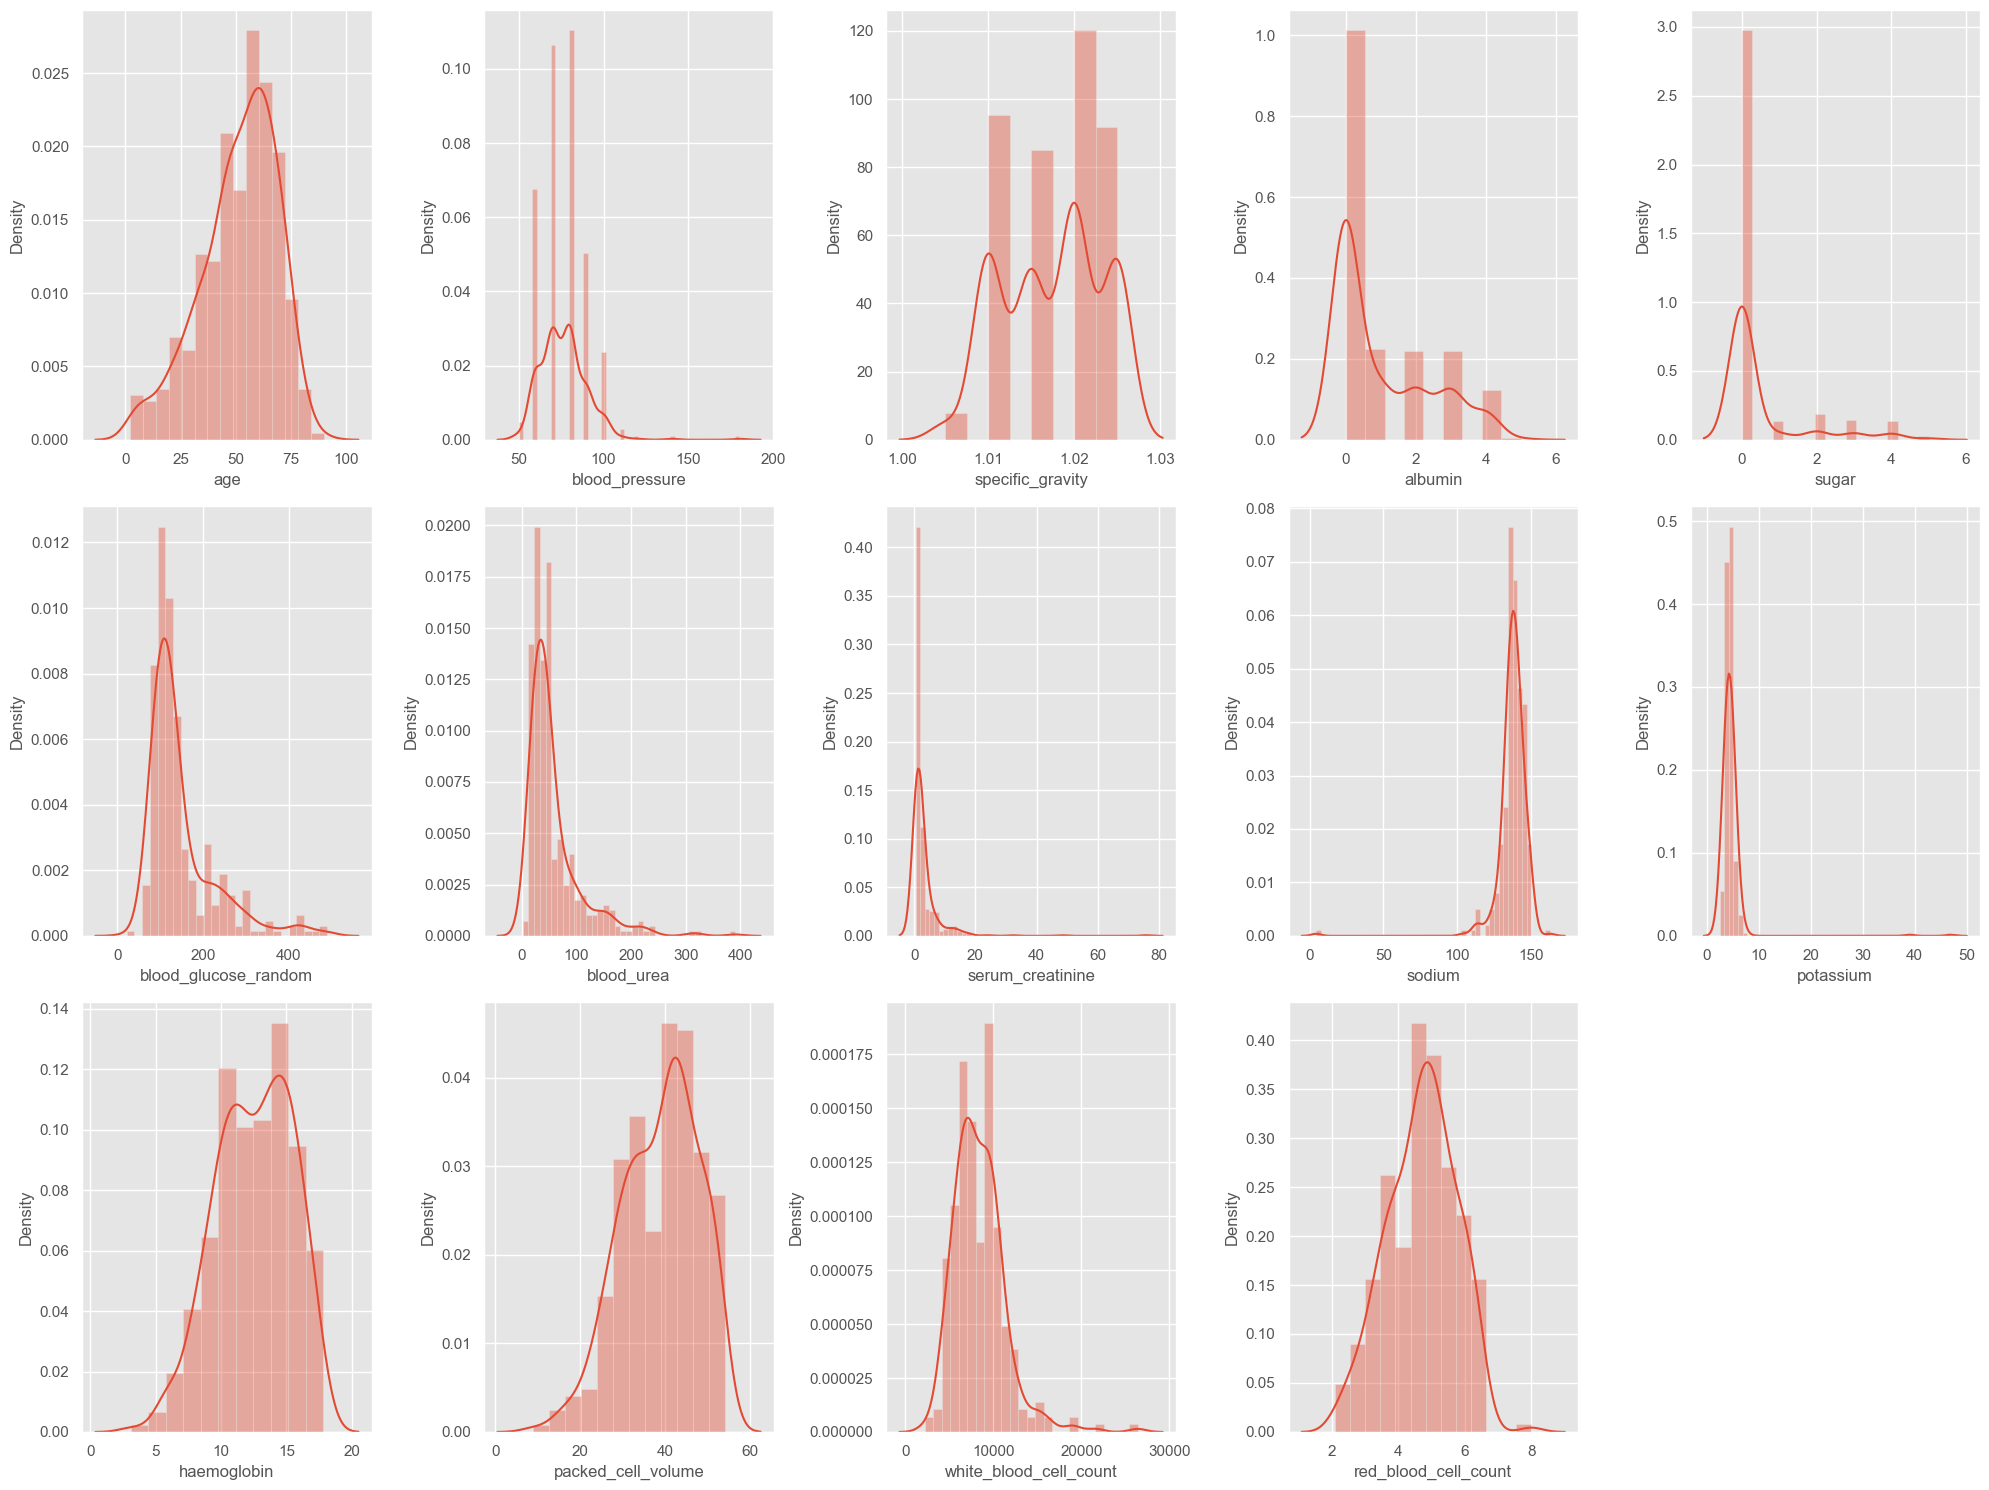

In [22]:
# plot the distributions of all numerical columns (num_cols) from your dataframe in a grid of histograms.

plt.figure(figsize = (20,15))
plotnumber = 1  # Start subplot counter to track the position of each subplot in the grid.

for column in num_cols: # Loop through numeric columns
    if plotnumber <= 14:  # Limit to first 14 plots
        ax = plt.subplot(3, 5, plotnumber)   # Create subplot position to 3 rows, 5 columns and place plot in position 'plotnumber.'
        sns.distplot(df[column])  # Creates a histogram and density curve of the column values to see the value spread, skewness, outliers, and shape.
        plt.xlabel(column)
    plotnumber += 1   # Move to next subplot
plt.tight_layout()  # adjust the spacing to prevent overlapping labels between subplots.
plt.show()

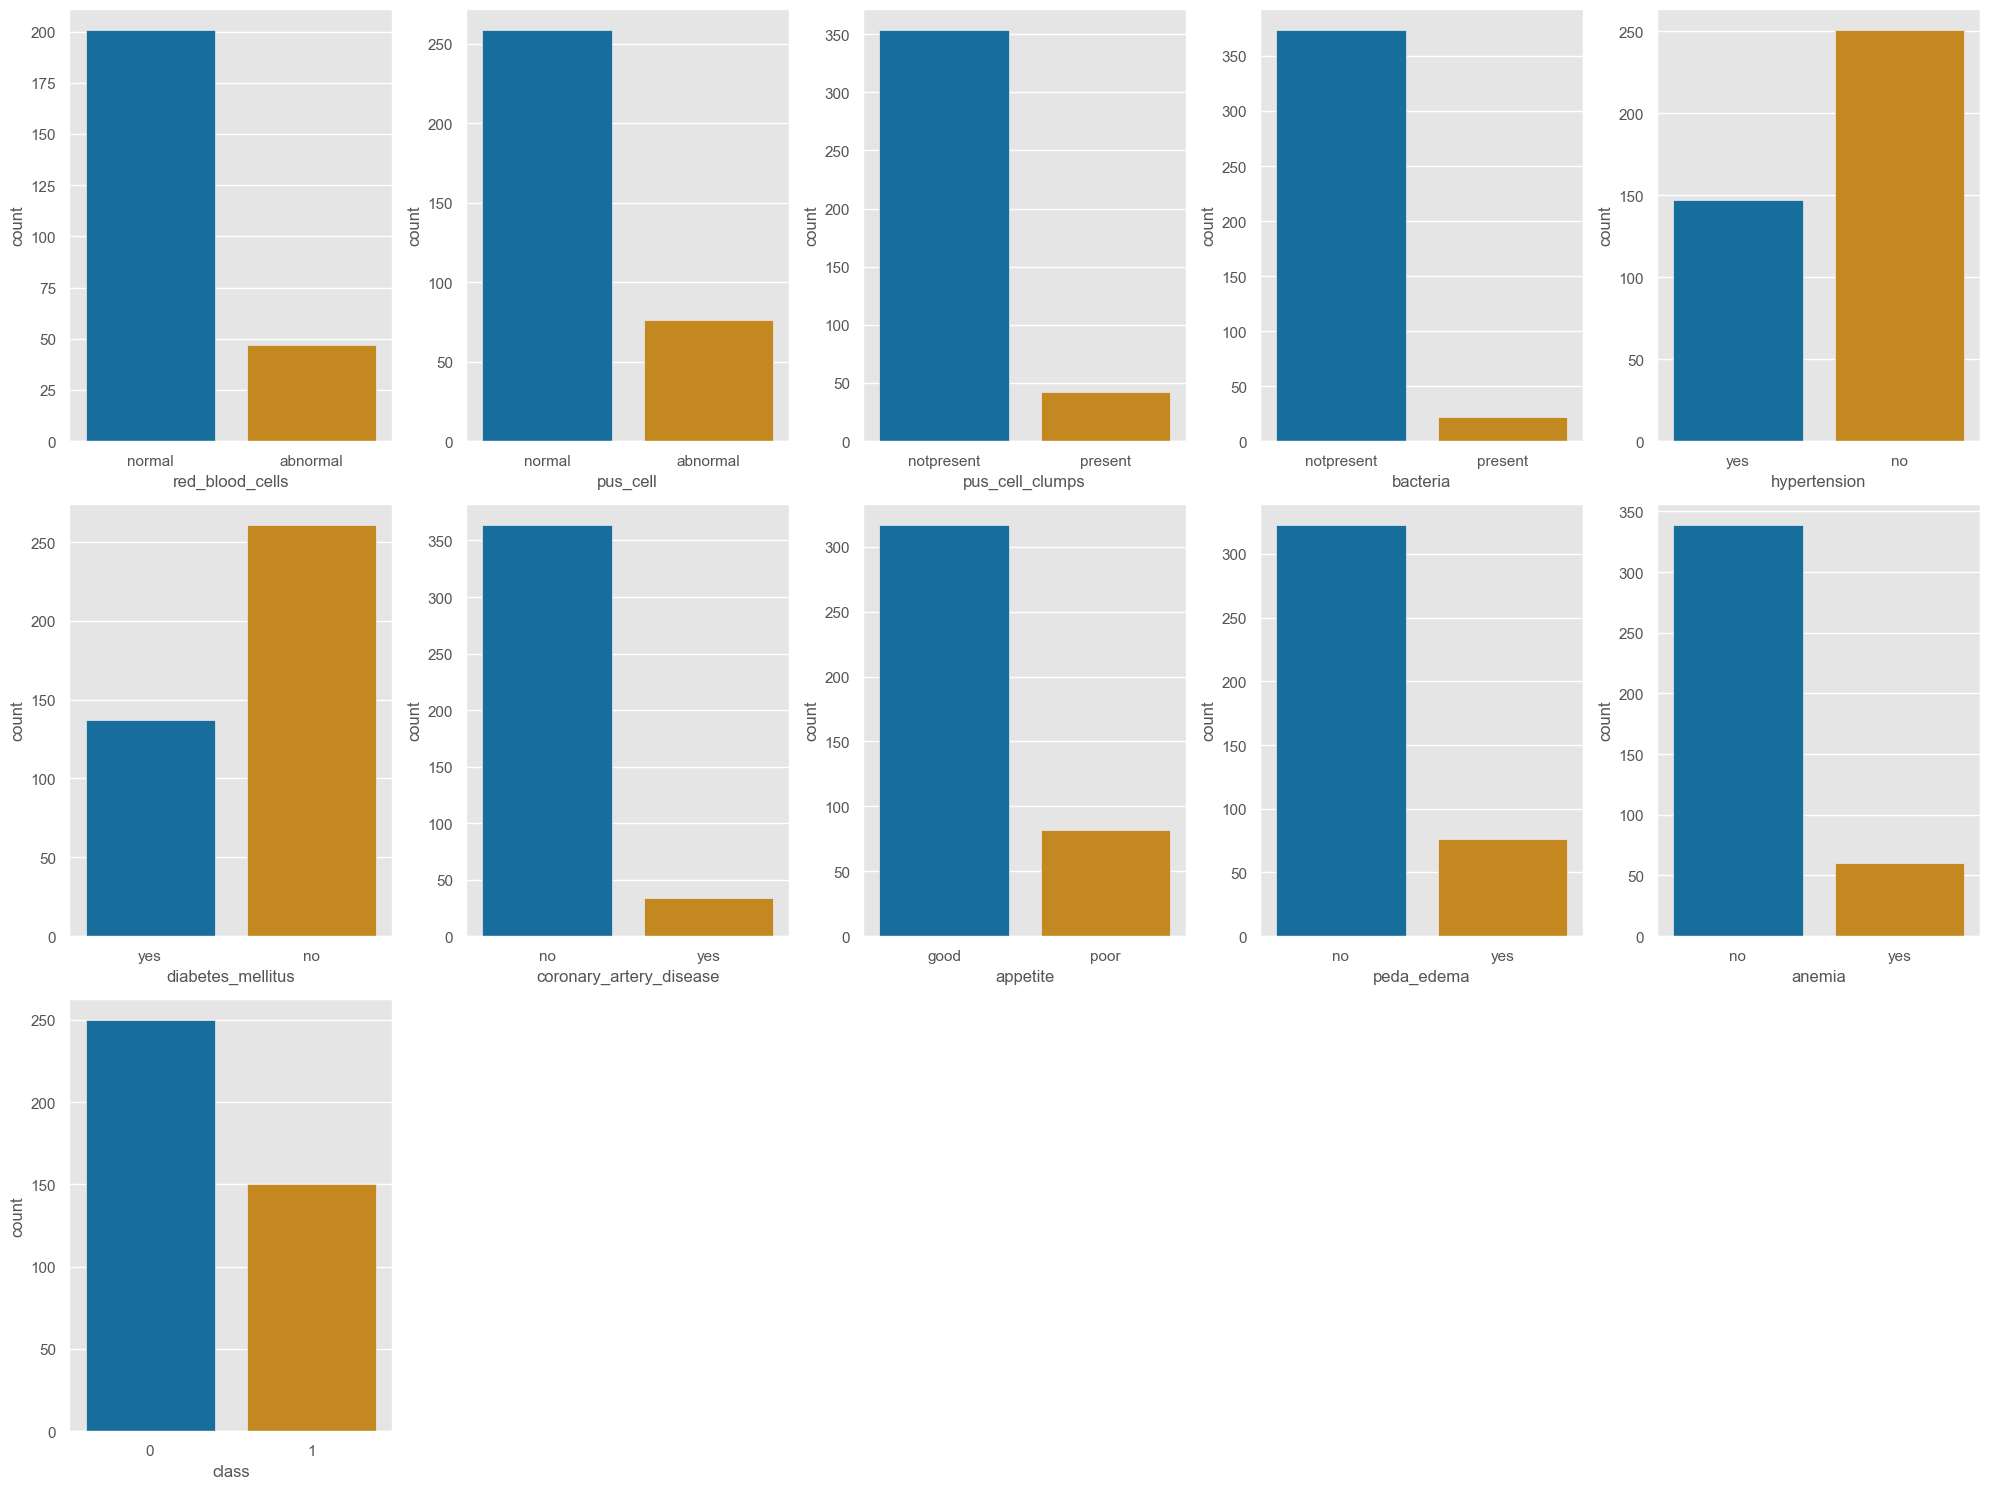

In [23]:
# plot the distributions of all categorical columns (cat_cols) from your dataframe.

plt.figure(figsize = (20,15))
plotnumber = 1  # Start subplot counter to track the position of each subplot in the grid.

for column in cat_cols: # Loop through categorical columns
    if plotnumber <= 14:  # Limit to first 14 plots
        ax = plt.subplot(3, 5, plotnumber)   # Create subplot position to 3 rows, 5 columns and place plot in position 'plotnumber.'
        sns.countplot(x=df[column], palette = 'colorblind') 
        plt.xlabel(column)
    plotnumber += 1   # Move to next subplot
plt.tight_layout()  # adjust the spacing to prevent overlapping labels between subplots.
plt.show()

In [24]:
df.corr(numeric_only=True)

,age,blood_pressure,specific_gravity,albumin,sugar,blood_glucose_random,blood_urea,serum_creatinine,sodium,potassium,haemoglobin,packed_cell_volume,white_blood_cell_count,red_blood_cell_count,class
age,1.000000,0.159480,-0.191096,0.122091,0.220866,0.244992,0.196985,0.132531,-0.100046,0.058377,-0.192928,-0.242119,0.118339,-0.268896,-0.227268
blood_pressure,0.159480,1.000000,-0.218836,0.160689,0.222576,0.160193,0.188517,0.146222,-0.116422,0.075151,-0.306540,-0.326319,0.029753,-0.261936,-0.294077
specific_gravity,-0.191096,-0.218836,1.000000,-0.469760,-0.296234,-0.374710,-0.314295,-0.361473,0.412190,-0.072787,0.602582,0.603560,-0.236215,0.579476,0.732163
albumin,0.122091,0.160689,-0.469760,1.000000,0.269305,0.379464,0.453528,0.399198,-0.459896,0.129038,-0.634632,-0.611891,0.231989,-0.566437,-0.627090
sugar,0.220866,0.222576,-0.296234,0.269305,1.000000,0.717827,0.168583,0.223244,-0.131776,0.219450,-0.224775,-0.239189,0.184893,-0.237448,-0.344070
blood_glucose_random,0.244992,0.160193,-0.374710,0.379464,0.717827,1.000000,0.143322,0.114875,-0.267848,0.066966,-0.306189,-0.301385,0.150015,-0.281541,-0.419672
blood_urea,0.196985,0.188517,-0.314295,0.453528,0.168583,0.143322,1.000000,0.586368,-0.323054,0.357049,-0.610360,-0.607621,0.050462,-0.579087,-0.380605
serum_creatinine,0.132531,0.146222,-0.361473,0.399198,0.223244,0.114875,0.586368,1.000000,-0.690158,0.326107,-0.401670,-0.404193,-0.006390,-0.400852,-0.299969
sodium,-0.100046,-0.116422,0.412190,-0.459896,-0.131776,-0.267848,-0.323054,-0.690158,1.000000,0.097887,0.365183,0.376914,0.007277,0.344873,0.375674
potassium,0.058377,0.075151,-0.072787,0.129038,0.219450,0.066966,0.357049,0.326107,0.097887,1.000000,-0.133746,-0.163182,-0.105576,-0.158309,-0.084541


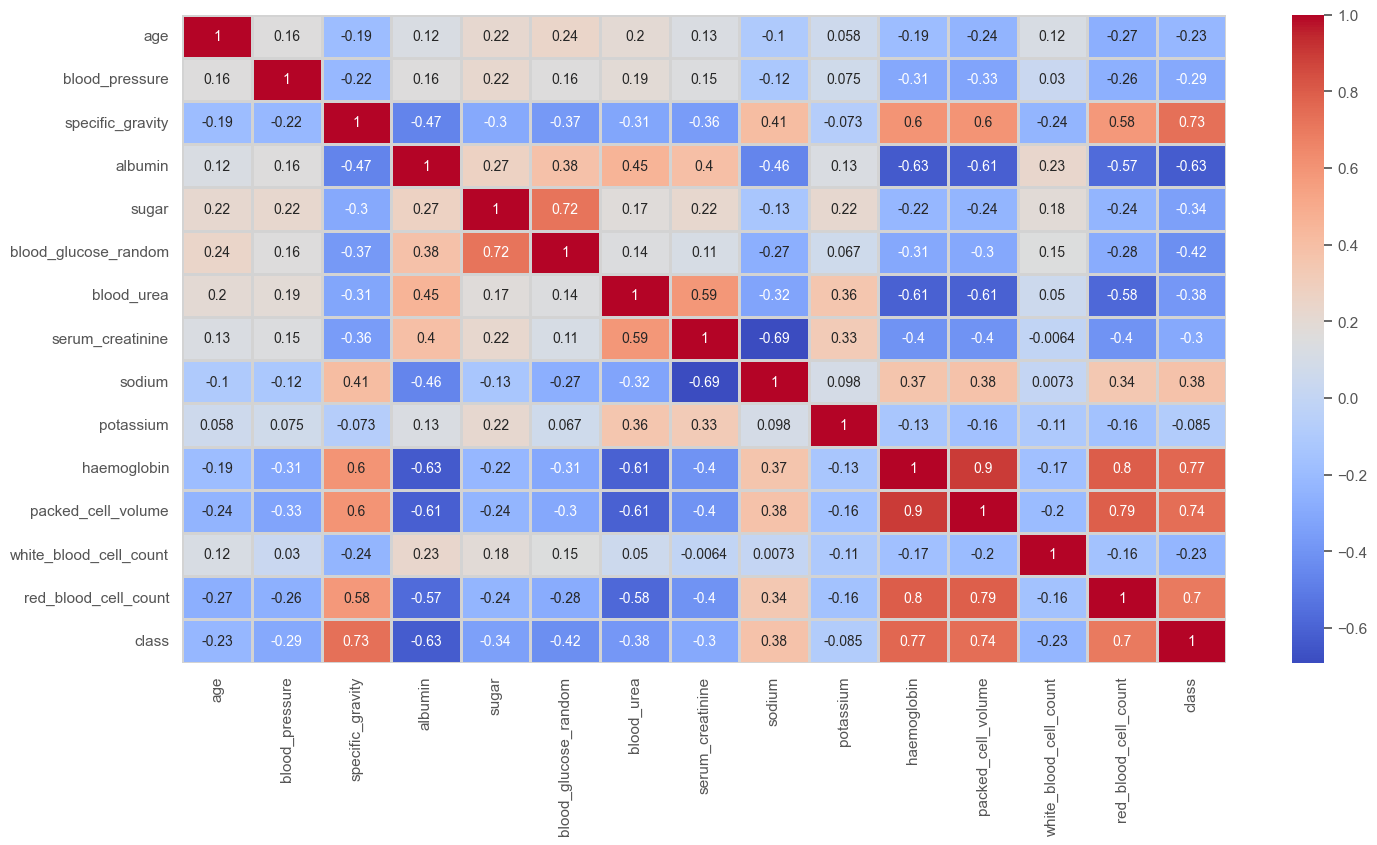

In [25]:
plt.figure(figsize = (15,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", linewidth=2, linecolor = 'lightgray')
plt.show()

In [26]:
# EDA

In [27]:
# we can use helper visualization functions to quickly explore CKD features by class (CKD vs non-CKD).

def voilin(col): # Create a violin plot of a numeric feature (col) grouped by CKD class.
    fig = px.violin(df, y=col, x='class', color='class', box=True, template='plotly_dark')
    return fig.show()

def kde(col): # Create a KDE density curve of a feature by class
    grid = sns.FacetGrid(df, hue='class', height = 6, aspect = 2)
    grid.map(sns.kdeplot, col)
    grid.add_legend()

def scatter_plot(col1, col2): # Create a scatter plot of two features, colored by CKD class
    fig = px.scatter(df, x=col1, y=col2, color='class', box=True, template='plotly_dark')
    return fig.show()

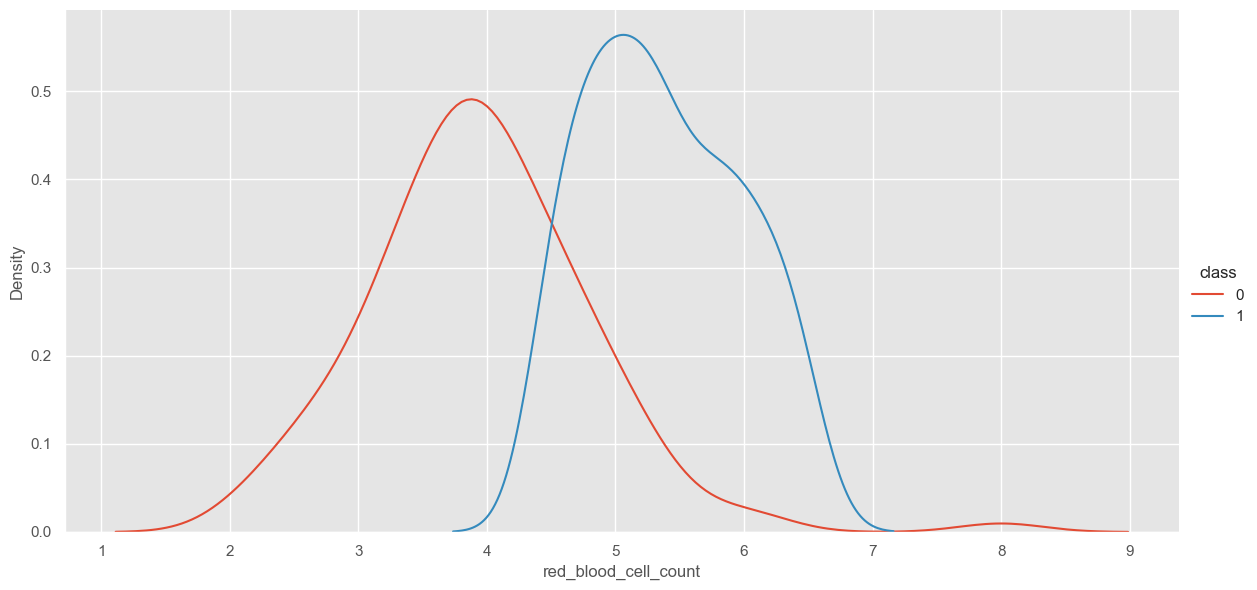

In [28]:
kde('red_blood_cell_count')  # to see the CKD density curve, Not CKD curve, and separation between classes

## Data Preprocessing

In [29]:
# check for missing values

df.isnull().sum().sort_values(ascending=False)

red_blood_cells            152
red_blood_cell_count       131
white_blood_cell_count     106
potassium                   88
sodium                      87
packed_cell_volume          71
pus_cell                    65
haemoglobin                 52
sugar                       49
specific_gravity            47
albumin                     46
blood_glucose_random        44
blood_urea                  19
serum_creatinine            17
blood_pressure              12
age                          9
pus_cell_clumps              4
bacteria                     4
hypertension                 2
diabetes_mellitus            2
coronary_artery_disease      2
appetite                     1
peda_edema                   1
anemia                       1
class                        0
dtype: int64

In [30]:
df[num_cols].isnull().sum()

age                         9
blood_pressure             12
specific_gravity           47
albumin                    46
sugar                      49
blood_glucose_random       44
blood_urea                 19
serum_creatinine           17
sodium                     87
potassium                  88
haemoglobin                52
packed_cell_volume         71
white_blood_cell_count    106
red_blood_cell_count      131
dtype: int64

In [31]:
df[cat_cols].isnull().sum()

red_blood_cells            152
pus_cell                    65
pus_cell_clumps              4
bacteria                     4
hypertension                 2
diabetes_mellitus            2
coronary_artery_disease      2
appetite                     1
peda_edema                   1
anemia                       1
class                        0
dtype: int64

In [32]:
df.head()

,age,blood_pressure,specific_gravity,albumin,sugar,red_blood_cells,pus_cell,pus_cell_clumps,bacteria,blood_glucose_random,...,packed_cell_volume,white_blood_cell_count,red_blood_cell_count,hypertension,diabetes_mellitus,coronary_artery_disease,appetite,peda_edema,anemia,class
0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,...,44.0,7800.0,5.2,yes,yes,no,good,no,no,0
1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,...,38.0,6000.0,NaN,no,no,no,good,no,no,0
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,...,31.0,7500.0,NaN,no,yes,no,poor,no,yes,0
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,...,32.0,6700.0,3.9,yes,no,no,poor,yes,yes,0
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,...,35.0,7300.0,4.6,no,no,no,good,no,no,0


In [33]:
# 

# method one: randomm sampling ------ higher null value
# mean/mode ------- lower null value

In [34]:
def random_sampling(feature):
    random_sample = df[feature].dropna().sample(df[feature].isna().sum())
    random_sample.index = df[df[feature].isnull()].index
    df.loc[df[feature].isnull(), feature] = random_sample

def impute_mode(feature):
    mode = df[feature].mode()[0]
    df[feature] = df[feature].fillna(mode)

In [35]:
# random sampling for numerical values

for col in num_cols:
    random_sampling(col)

In [36]:
df[num_cols].isnull().sum()

age                       0
blood_pressure            0
specific_gravity          0
albumin                   0
sugar                     0
blood_glucose_random      0
blood_urea                0
serum_creatinine          0
sodium                    0
potassium                 0
haemoglobin               0
packed_cell_volume        0
white_blood_cell_count    0
red_blood_cell_count      0
dtype: int64

In [37]:
random_sampling('red_blood_cells')
random_sampling('pus_cell')

for col in cat_cols:
    impute_mode(col)

In [38]:
df[cat_cols].isnull().sum()

red_blood_cells            0
pus_cell                   0
pus_cell_clumps            0
bacteria                   0
hypertension               0
diabetes_mellitus          0
coronary_artery_disease    0
appetite                   0
peda_edema                 0
anemia                     0
class                      0
dtype: int64

## feature encoding

In [39]:
for col in cat_cols:
    print(f"{col} has {df[col].nunique()}")

red_blood_cells has 2
pus_cell has 2
pus_cell_clumps has 2
bacteria has 2
hypertension has 2
diabetes_mellitus has 2
coronary_artery_disease has 2
appetite has 2
peda_edema has 2
anemia has 2
class has 2


In [40]:
# label encoder

from sklearn.preprocessing import LabelEncoder

In [41]:
le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

In [42]:
df.head()

,age,blood_pressure,specific_gravity,albumin,sugar,red_blood_cells,pus_cell,pus_cell_clumps,bacteria,blood_glucose_random,...,packed_cell_volume,white_blood_cell_count,red_blood_cell_count,hypertension,diabetes_mellitus,coronary_artery_disease,appetite,peda_edema,anemia,class
0,48.0,80.0,1.020,1.0,0.0,1,1,0,0,121.0,...,44.0,7800.0,5.2,1,1,0,0,0,0,0
1,7.0,50.0,1.020,4.0,0.0,0,1,0,0,78.0,...,38.0,6000.0,4.8,0,0,0,0,0,0,0
2,62.0,80.0,1.010,2.0,3.0,1,1,0,0,423.0,...,31.0,7500.0,3.8,0,1,0,1,0,1,0
3,48.0,70.0,1.005,4.0,0.0,1,0,1,0,117.0,...,32.0,6700.0,3.9,1,0,0,1,1,1,0
4,51.0,80.0,1.010,2.0,0.0,1,1,0,0,106.0,...,35.0,7300.0,4.6,0,0,0,0,0,0,0


#### as you can see above there are no missing values

## Model Building

In [43]:
X = df.drop('class', axis = 1)
y = df['class']

In [44]:
X

,age,blood_pressure,specific_gravity,albumin,sugar,red_blood_cells,pus_cell,pus_cell_clumps,bacteria,blood_glucose_random,...,haemoglobin,packed_cell_volume,white_blood_cell_count,red_blood_cell_count,hypertension,diabetes_mellitus,coronary_artery_disease,appetite,peda_edema,anemia
0,48.0,80.0,1.020,1.0,0.0,1,1,0,0,121.0,...,15.4,44.0,7800.0,5.2,1,1,0,0,0,0
1,7.0,50.0,1.020,4.0,0.0,0,1,0,0,78.0,...,11.3,38.0,6000.0,4.8,0,0,0,0,0,0
2,62.0,80.0,1.010,2.0,3.0,1,1,0,0,423.0,...,9.6,31.0,7500.0,3.8,0,1,0,1,0,1
3,48.0,70.0,1.005,4.0,0.0,1,0,1,0,117.0,...,11.2,32.0,6700.0,3.9,1,0,0,1,1,1
4,51.0,80.0,1.010,2.0,0.0,1,1,0,0,106.0,...,11.6,35.0,7300.0,4.6,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,55.0,80.0,1.020,0.0,0.0,1,1,0,0,140.0,...,15.7,47.0,6700.0,4.9,0,0,0,0,0,0
396,42.0,70.0,1.025,0.0,0.0,1,1,0,0,75.0,...,16.5,54.0,7800.0,6.2,0,0,0,0,0,0
397,12.0,80.0,1.020,0.0,0.0,1,1,0,0,100.0,...,15.8,49.0,6600.0,5.4,0,0,0,0,0,0
398,17.0,60.0,1.025,0.0,0.0,1,1,0,0,114.0,...,14.2,51.0,7200.0,5.9,0,0,0,0,0,0


In [45]:
y

0      0
1      0
2      0
3      0
4      0
      ..
395    1
396    1
397    1
398    1
399    1
Name: class, Length: 400, dtype: int64

In [46]:
# classify the data into dependent and independent variables

from sklearn.model_selection import train_test_split

In [47]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [48]:
# use KNN

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [49]:
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [50]:
knn_acc = accuracy_score(y_test, knn.predict(X_test))
print(f"Training Accuracy of KNN is {accuracy_score(y_train, knn.predict(X_train))}")
print(f"Testing Accuracy of KNN is {accuracy_score(y_test, knn.predict(X_test))}")

print(f"Confusion Matrix of KNN is \n {confusion_matrix(y_test, knn.predict(X_test))}\n")
print(f"Classification Report of KNN is \n {classification_report(y_test, knn.predict(X_test))}\n")

Training Accuracy of KNN is 0.803125
Testing Accuracy of KNN is 0.7375
Confusion Matrix of KNN is 
 [[38 14]
 [ 7 21]]

Classification Report of KNN is 
               precision    recall  f1-score   support

           0       0.84      0.73      0.78        52
           1       0.60      0.75      0.67        28

    accuracy                           0.74        80
   macro avg       0.72      0.74      0.73        80
weighted avg       0.76      0.74      0.74        80




In [51]:
# Decision Tree

from sklearn.tree import DecisionTreeClassifier

In [52]:
dtc = DecisionTreeClassifier()
dtc.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [53]:
dtc_acc = accuracy_score(y_test, dtc.predict(X_test))
print(f"Training Accuracy of DTC is {accuracy_score(y_train, dtc.predict(X_train))}")
print(f"Testing Accuracy of DTC is {accuracy_score(y_test, dtc.predict(X_test))}")

print(f"Confusion Matrix of DTC is \n {confusion_matrix(y_test, dtc.predict(X_test))}\n")
print(f"Classification Report of DTC is \n {classification_report(y_test, dtc.predict(X_test))}\n")

Training Accuracy of DTC is 1.0
Testing Accuracy of DTC is 0.9875
Confusion Matrix of DTC is 
 [[51  1]
 [ 0 28]]

Classification Report of DTC is 
               precision    recall  f1-score   support

           0       1.00      0.98      0.99        52
           1       0.97      1.00      0.98        28

    accuracy                           0.99        80
   macro avg       0.98      0.99      0.99        80
weighted avg       0.99      0.99      0.99        80




In [54]:
# Hyper Parameter Tuning

from sklearn.model_selection import GridSearchCV

In [55]:
GRID_PARAMETER = {
    'criterion':['gini', 'entropy'],
    'max_depth':[3,5,7,10],
    'splitter':['best','random'],
    'min_samples_leaf':[1,2,3,5,7],
    'min_samples_split':[1,2,3,5,7],
    'max_features':['auto', 'sqrt', 'log2']
}

In [56]:
grid_search_dtc = GridSearchCV(dtc, GRID_PARAMETER, cv=5, n_jobs=-1, verbose = 1)
grid_search_dtc.fit(X_train, y_train)

Fitting 5 folds for each of 1200 candidates, totalling 6000 fits


,estimator,DecisionTreeClassifier()
,param_grid,"{'criterion': ['gini', 'entropy'], 'max_depth': [3, 5, ...], 'max_features': ['auto', 'sqrt', ...], 'min_samples_leaf': [1, 2, ...], ...}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [57]:
# best parameter and best score

print(grid_search_dtc.best_params_)
print(grid_search_dtc.best_score_)

{'criterion': 'gini', 'max_depth': 7, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 7, 'splitter': 'best'}
0.975


In [58]:
dtc = grid_search_dtc.best_estimator_

dtc_acc = accuracy_score(y_test, dtc.predict(X_test))
print(f"Training Accuracy of DTC is {accuracy_score(y_train, dtc.predict(X_train))}")
print(f"Testing Accuracy of DTC is {accuracy_score(y_test, dtc.predict(X_test))}")

print(f"Confusion Matrix of DTC is \n {confusion_matrix(y_test, dtc.predict(X_test))}\n")
print(f"Classification Report of DTC is \n {classification_report(y_test, dtc.predict(X_test))}\n")

Training Accuracy of DTC is 0.971875
Testing Accuracy of DTC is 0.975
Confusion Matrix of DTC is 
 [[51  1]
 [ 1 27]]

Classification Report of DTC is 
               precision    recall  f1-score   support

           0       0.98      0.98      0.98        52
           1       0.96      0.96      0.96        28

    accuracy                           0.97        80
   macro avg       0.97      0.97      0.97        80
weighted avg       0.97      0.97      0.97        80




In [59]:
# Random Forest Classifier

from sklearn.ensemble import RandomForestClassifier 

In [60]:
rand_for_cl = RandomForestClassifier(
    criterion = "gini", 
    max_depth = 10, 
    max_features="sqrt", 
    min_samples_leaf = 1, 
    min_samples_split = 7, 
    n_estimators = 400)

In [61]:
rand_for_cl.fit(X_train, y_train)

,n_estimators,400
,criterion,'gini'
,max_depth,10
,min_samples_split,7
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [62]:
rand_for_cl_acc = accuracy_score(y_test, rand_for_cl.predict(X_test))
print(f"Training Accuracy of Random Forest is {accuracy_score(y_train, rand_for_cl.predict(X_train))}")
print(f"Testing Accuracy of Random Forest is {accuracy_score(y_test, rand_for_cl.predict(X_test))}")

print(f"Confusion Matrix of Random Forest is \n {confusion_matrix(y_test, rand_for_cl.predict(X_test))}\n")
print(f"Classification Report of Random Forest is \n {classification_report(y_test, rand_for_cl.predict(X_test))}\n")

Training Accuracy of Random Forest is 0.996875
Testing Accuracy of Random Forest is 1.0
Confusion Matrix of Random Forest is 
 [[52  0]
 [ 0 28]]

Classification Report of Random Forest is 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        52
           1       1.00      1.00      1.00        28

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80




In [63]:
# XGBoost

from xgboost import XGBClassifier

In [64]:
xgb = XGBClassifier(objective="binary:logistic", learning_rate = 0.01, max_depth = 10, n_estimators = 100)
xgb.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [65]:
xgb_acc = accuracy_score(y_test, xgb.predict(X_test))
print(f"Training Accuracy of XGB is {accuracy_score(y_train, xgb.predict(X_train))}")
print(f"Testing Accuracy of XGB is {accuracy_score(y_test, xgb.predict(X_test))}")

print(f"Confusion Matrix of XGB is \n {confusion_matrix(y_test, xgb.predict(X_test))}\n")
print(f"Classification Report of XGB is \n {classification_report(y_test, xgb.predict(X_test))}\n")

Training Accuracy of XGB is 0.9875
Testing Accuracy of XGB is 1.0
Confusion Matrix of XGB is 
 [[52  0]
 [ 0 28]]

Classification Report of XGB is 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        52
           1       1.00      1.00      1.00        28

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80




In [66]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [67]:
lr_acc = accuracy_score(y_test, lr.predict(X_test))
print(f"Training Accuracy of Logistic Regression is {accuracy_score(y_train, lr.predict(X_train))}")
print(f"Testing Accuracy of Logistic Regression is {accuracy_score(y_test, lr.predict(X_test))}")

print(f"Confusion Matrix of Logistic Regression is \n {confusion_matrix(y_test, lr.predict(X_test))}\n")
print(f"Classification Report of Logistic Regression is \n {classification_report(y_test, lr.predict(X_test))}\n")

Training Accuracy of Logistic Regression is 0.88125
Testing Accuracy of Logistic Regression is 0.8875
Confusion Matrix of Logistic Regression is 
 [[46  6]
 [ 3 25]]

Classification Report of Logistic Regression is 
               precision    recall  f1-score   support

           0       0.94      0.88      0.91        52
           1       0.81      0.89      0.85        28

    accuracy                           0.89        80
   macro avg       0.87      0.89      0.88        80
weighted avg       0.89      0.89      0.89        80




In [68]:
# SVM

from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

In [69]:
svm = SVC(probability=True)

parameter = {
    'gamma': [0.0001, 0.001, 0.01, 0.1],
    'C': [0.01, 0.05, 0.5, 0.1, 1, 10, 15, 20]
}

In [70]:
grid_search = GridSearchCV(svm, parameter)
grid_search.fit(X_train, y_train)

,estimator,SVC(probability=True)
,param_grid,"{'C': [0.01, 0.05, ...], 'gamma': [0.0001, 0.001, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,10


In [71]:
print(grid_search.best_params_)
print(grid_search.best_score_)

{'C': 10, 'gamma': 0.0001}
0.728125


In [72]:
svm = SVC(gamma = 0.001, C = 10, probability=True)

In [73]:
svm.fit(X_train, y_train)

,C,10
,kernel,'rbf'
,degree,3
,gamma,0.001
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [74]:
svm_acc = accuracy_score(y_test, svm.predict(X_test))
print(f"Training Accuracy of SVC is {accuracy_score(y_train, svm.predict(X_train))}")
print(f"Testing Accuracy of SVC is {accuracy_score(y_test, svm.predict(X_test))}")

print(f"Confusion Matrix of SVC is \n {confusion_matrix(y_test, svm.predict(X_test))}\n")
print(f"Classification Report of SVC is \n {classification_report(y_test, svm.predict(X_test))}\n")

Training Accuracy of SVC is 1.0
Testing Accuracy of SVC is 0.7375
Confusion Matrix of SVC is 
 [[46  6]
 [15 13]]

Classification Report of SVC is 
               precision    recall  f1-score   support

           0       0.75      0.88      0.81        52
           1       0.68      0.46      0.55        28

    accuracy                           0.74        80
   macro avg       0.72      0.67      0.68        80
weighted avg       0.73      0.74      0.72        80




In [75]:
# WE APPLY ONE LAST MACHINE LEARNING ALGORITHMS

from sklearn.ensemble import GradientBoostingClassifier

In [76]:
gbc = GradientBoostingClassifier()

In [77]:
PARAMETERS = {
    'loss': ['log_loss', 'exponential'],
    'learning_rate': [0.001, 0.1, 1, 10],
    'n_estimators': [100, 150, 180, 200]
}

grid_search_gbc = GridSearchCV(gbc, PARAMETERS, cv=5, n_jobs=-1, verbose = 1)
grid_search_gbc.fit(X_train, y_train)

Fitting 5 folds for each of 32 candidates, totalling 160 fits


,estimator,GradientBoostingClassifier()
,param_grid,"{'learning_rate': [0.001, 0.1, ...], 'loss': ['log_loss', 'exponential'], 'n_estimators': [100, 150, ...]}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,loss,'exponential'


In [78]:
print(grid_search_gbc.best_params_)

{'learning_rate': 0.1, 'loss': 'exponential', 'n_estimators': 200}


In [79]:
print(grid_search_gbc.best_score_)

0.98125


In [80]:
gbc = GradientBoostingClassifier(learning_rate = 1, loss = 'exponential', n_estimators = 100)
gbc.fit(X_train, y_train)

,loss,'exponential'
,learning_rate,1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [81]:
gbc_acc = accuracy_score(y_test, gbc.predict(X_test))
print(f"Training Accuracy of GBC is {accuracy_score(y_train, gbc.predict(X_train))}")
print(f"Testing Accuracy of GBC is {accuracy_score(y_test, gbc.predict(X_test))}")

print(f"Confusion Matrix of GBC is \n {confusion_matrix(y_test, gbc.predict(X_test))}\n")
print(f"Classification Report of GBC is \n {classification_report(y_test, gbc.predict(X_test))}\n")

Training Accuracy of GBC is 1.0
Testing Accuracy of GBC is 1.0
Confusion Matrix of GBC is 
 [[52  0]
 [ 0 28]]

Classification Report of GBC is 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        52
           1       1.00      1.00      1.00        28

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80




In [84]:
# model comparisons


models = pd.DataFrame({
    'Model': ['Logistic Regression', 'KNN', 'SVM', 'DT', 'Random Forest Classifier', 'XgBoost', 'Gradient Boosting'],
    'Score': [
        round(lr_acc, 5),
        round(knn_acc, 5),
        round(svm_acc, 5),
        round(dtc_acc, 5),
        round(rand_for_cl_acc, 5),
        round(gbc_acc, 5),
        round(xgb_acc, 5)
    ]
})

In [86]:
models = models.sort_values(by='Score', ascending=False)
models['Score_percent'] = models['Score'] * 100
models['Score_percent'] = models['Score_percent'].map(lambda x: f"{x:.2f}%")

In [87]:
models

,Model,Score,Score_percent
6,Gradient Boosting,1.0000,100.00%
5,XgBoost,1.0000,100.00%
4,Random Forest Classifier,1.0000,100.00%
3,DT,0.9750,97.50%
0,Logistic Regression,0.8875,88.75%
2,SVM,0.7375,73.75%
1,KNN,0.7375,73.75%


In [88]:
import pickle
from sklearn import metrics
import matplotlib.pyplot as plt

In [90]:
# Save model
pickle.dump(dtc, open("kidney.pkl", 'wb'))

plt.figure(figsize=(8,5))

models = [
    {'label': 'LR', 'model': lr},
    {'label': 'DT', 'model': dtc},
    {'label': 'SVM', 'model': svm},
    {'label': 'KNN', 'model': knn},
    {'label': 'XGBoost', 'model': xgb},
    {'label': 'RF', 'model': rand_for_cl},
    {'label': 'GBDT', 'model': gbc}
]

<Figure size 800x500 with 0 Axes>

In [91]:
# Train models first
for m in models:
    m['model'].fit(X_train, y_train)

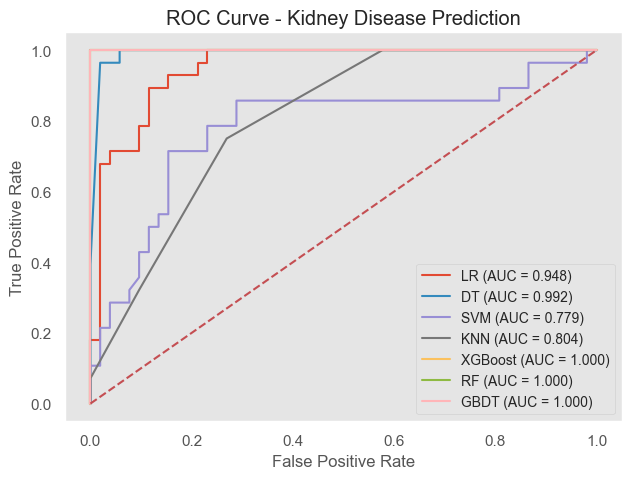

In [92]:
# Plot ROC curves
for m in models:
    model = m['model']
    
    y_prob = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = metrics.roc_curve(y_test, y_prob)
    auc = metrics.roc_auc_score(y_test, y_prob)
    
    plt.plot(fpr, tpr, label=f"{m['label']} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Kidney Disease Prediction')

plt.legend(loc="lower right", fontsize=10)
plt.grid()

plt.savefig("roc_kidney.jpeg", dpi=400, bbox_inches='tight')
plt.show()

In [93]:
from sklearn import metrics
import numpy as np
import matplotlib.pyplot as plt

# Models list

models = [
    {'label': 'LR', 'model': lr},
    {'label': 'DT', 'model': dtc},
    {'label': 'SVM', 'model': svm},
    {'label': 'KNN', 'model': knn},
    {'label': 'XGBoost', 'model': xgb},
    {'label': 'RF', 'model': rand_for_cl},
    {'label': 'GBDT', 'model': gbc}
]

Accuracy (%): [88.75, 98.75, 73.75, 73.75, 100.0, 100.0, 100.0]
ROC-AUC (%): [94.85, 100.0, 77.88000000000001, 80.39, 100.0, 100.0, 100.0]


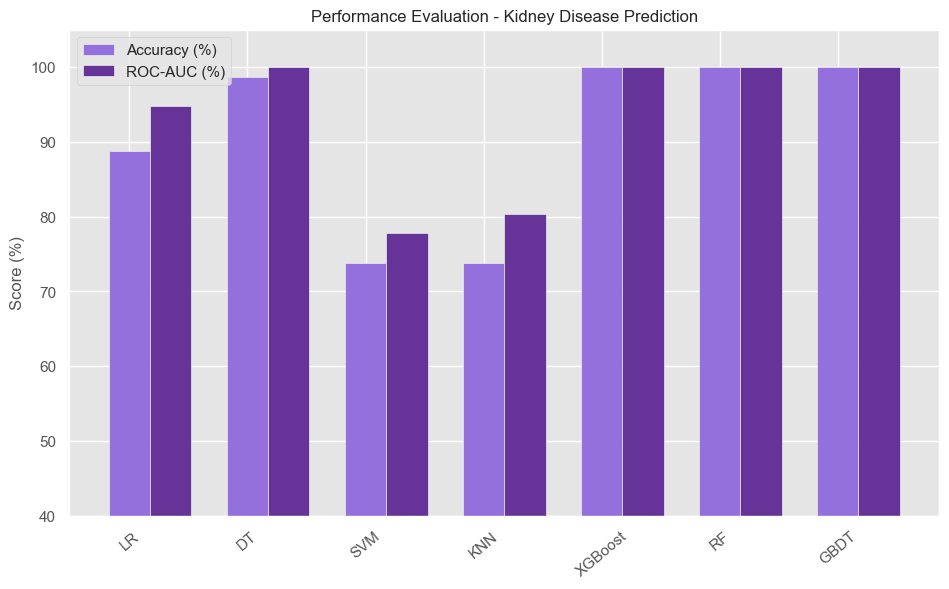

In [94]:
# Store results

means_roc = []
means_accuracy = []

for m in models:
    model = m['model']
    
    # Train model
    model.fit(X_train, y_train)
    
    # Predictions
    y_pred = model.predict(X_test)
    
    # Accuracy
    acc = metrics.accuracy_score(y_test, y_pred)
    means_accuracy.append(100 * round(acc, 4))
    
    # ROC-AUC
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        # fallback for models like SVM if probability=False
        y_prob = model.decision_function(X_test)
    
    auc = metrics.roc_auc_score(y_test, y_prob)
    means_roc.append(100 * round(auc, 4))

# Print results

print("Accuracy (%):", means_accuracy)
print("ROC-AUC (%):", means_roc)

# Plotting

n_groups = len(models)

index = np.arange(n_groups)
bar_width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

# Accuracy bars
plt.bar(index, means_accuracy, bar_width,
        color='mediumpurple',
        label='Accuracy (%)')

# ROC bars
plt.bar(index + bar_width, means_roc, bar_width,
        color='rebeccapurple',
        label='ROC-AUC (%)')

# Labels & formatting
plt.title('Performance Evaluation - Kidney Disease Prediction', fontsize=12)
plt.xticks(index, [m['label'] for m in models],
           rotation=40, ha='center', fontsize=11)

plt.ylabel("Score (%)")
plt.ylim([40, 105])
plt.legend()

# Save figure (portfolio ready)
plt.savefig("PE_kidney.jpeg", dpi=400, bbox_inches='tight')

plt.show()